# 04. 모델 비교

`02_preprocessing`에서 만든 동일한 train/val/test(66 피처)로 5개 분류 모델을 학습하고,  
공정하게 성능을 비교하여 최종 모델을 선택합니다.

## 비교 모델
- Random Forest
- XGBoost
- LightGBM
- TabNet (딥러닝, 탭형 데이터용)
- CatBoost

## 평가 지표
- **Accuracy**: 전체 정확도
- **F1-Score**: 위험 클래스 판별의 정밀도-재현율 균형
- **ROC-AUC**: 임계값과 무관한 판별력

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42

## 1. 전처리된 데이터 로드

`02_preprocessing`이 저장한 시계열 분할 데이터를 그대로 사용합니다.  
앞 3개 컬럼(자치구/업종/상권변화)은 범주형 인코딩된 피처입니다.

In [2]:
DATA = '../data/processed'

def load(split):
    X = pd.read_csv(f'{DATA}/{split}_features.csv', encoding='utf-8-sig')
    y = pd.read_csv(f'{DATA}/{split}_target.csv', encoding='utf-8-sig').iloc[:, 0].values
    return X, y

X_train, y_train = load('train')
X_val, y_val = load('val')
X_test, y_test = load('test')

cat_idx = [0, 1, 2]  # 자치구_encoded, 업종_encoded, 상권변화_encoded

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Test 클래스 분포: {np.bincount(y_test)}')

Train: (25812, 66), Val: (3687, 66), Test: (7376, 66)
Test 클래스 분포: [3568 3808]


In [3]:
# 결과 수집용
results = []
roc_data = {}

def evaluate(name, y_pred, y_proba):
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': auc})
    roc_data[name] = y_proba
    print(f'{name:14s} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

## 2. 트리 기반 모델 (RF / XGBoost / LightGBM)

In [4]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate('RandomForest', rf.predict(X_test), rf.predict_proba(X_test)[:, 1])

# XGBoost
xgb_clf = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                            random_state=SEED, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
evaluate('XGBoost', xgb_clf.predict(X_test), xgb_clf.predict_proba(X_test)[:, 1])

# LightGBM
lgb_clf = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, random_state=SEED, verbose=-1)
lgb_clf.fit(X_train, y_train)
evaluate('LightGBM', lgb_clf.predict(X_test), lgb_clf.predict_proba(X_test)[:, 1])

RandomForest   Acc=0.7021  F1=0.6771  AUC=0.7911


XGBoost        Acc=0.7002  F1=0.6808  AUC=0.7809


LightGBM       Acc=0.7013  F1=0.6801  AUC=0.7830


## 3. CatBoost

CatBoost는 범주형 변수를 직접 처리할 수 있어 `cat_features`로 인코딩된 3개 컬럼을 지정합니다.

In [5]:
cat_clf = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                             cat_features=cat_idx, random_seed=SEED, verbose=0)
cat_clf.fit(X_train, y_train)
evaluate('CatBoost', cat_clf.predict(X_test), cat_clf.predict_proba(X_test)[:, 1])

CatBoost       Acc=0.7127  F1=0.6944  AUC=0.7955


## 4. TabNet (딥러닝)

TabNet은 연속형 변수의 스케일에 민감하므로, 범주형(3개)을 제외한 연속형 피처만 표준화합니다.  
검증셋(val)으로 early stopping을 적용합니다.

In [6]:
# 연속형만 표준화
cont_cols = [c for i, c in enumerate(X_train.columns) if i not in cat_idx]
scaler = StandardScaler()

Xtr_s, Xval_s, Xte_s = X_train.copy(), X_val.copy(), X_test.copy()
Xtr_s[cont_cols] = scaler.fit_transform(X_train[cont_cols])
Xval_s[cont_cols] = scaler.transform(X_val[cont_cols])
Xte_s[cont_cols] = scaler.transform(X_test[cont_cols])

tabnet = TabNetClassifier(seed=SEED, verbose=0)
tabnet.fit(
    Xtr_s.values.astype(np.float32), y_train,
    eval_set=[(Xval_s.values.astype(np.float32), y_val)],
    eval_metric=['auc'], max_epochs=60, patience=15, batch_size=1024
)
tabnet_proba = tabnet.predict_proba(Xte_s.values.astype(np.float32))[:, 1]
evaluate('TabNet', (tabnet_proba >= 0.5).astype(int), tabnet_proba)

Stop training because you reached max_epochs = 60 with best_epoch = 49 and best_val_0_auc = 0.79909


TabNet         Acc=0.7015  F1=0.6723  AUC=0.7682


## 5. 성능 비교

In [7]:
results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
results_df.round(4)

,Accuracy,F1-Score,ROC-AUC
Model,,,
CatBoost,0.7127,0.6944,0.7955
RandomForest,0.7021,0.6771,0.7911
LightGBM,0.7013,0.6801,0.7830
XGBoost,0.7002,0.6808,0.7809
TabNet,0.7015,0.6723,0.7682


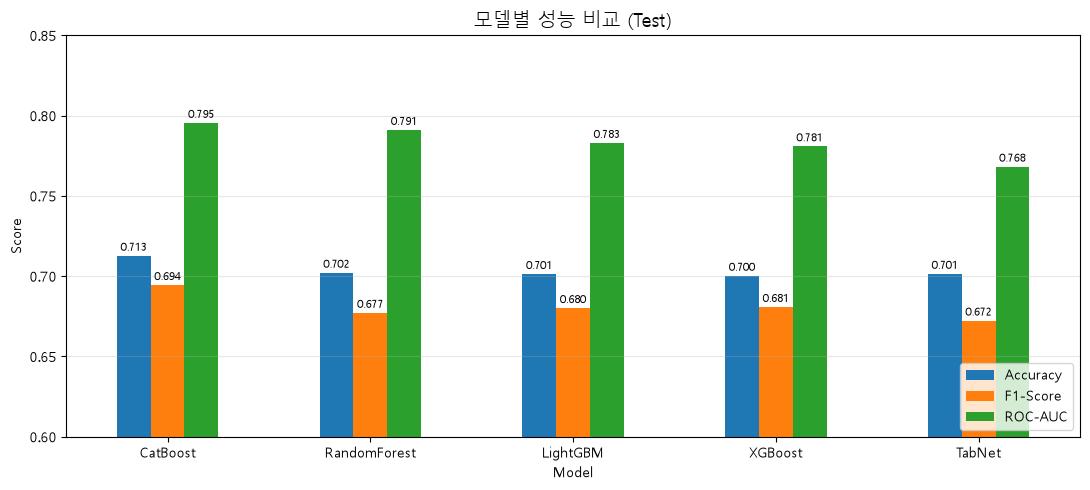

In [8]:
# 지표별 막대 그래프
ax = results_df.plot(kind='bar', figsize=(11, 5), rot=0, ylim=(0.6, 0.85))
ax.set_title('모델별 성능 비교 (Test)', fontsize=14)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

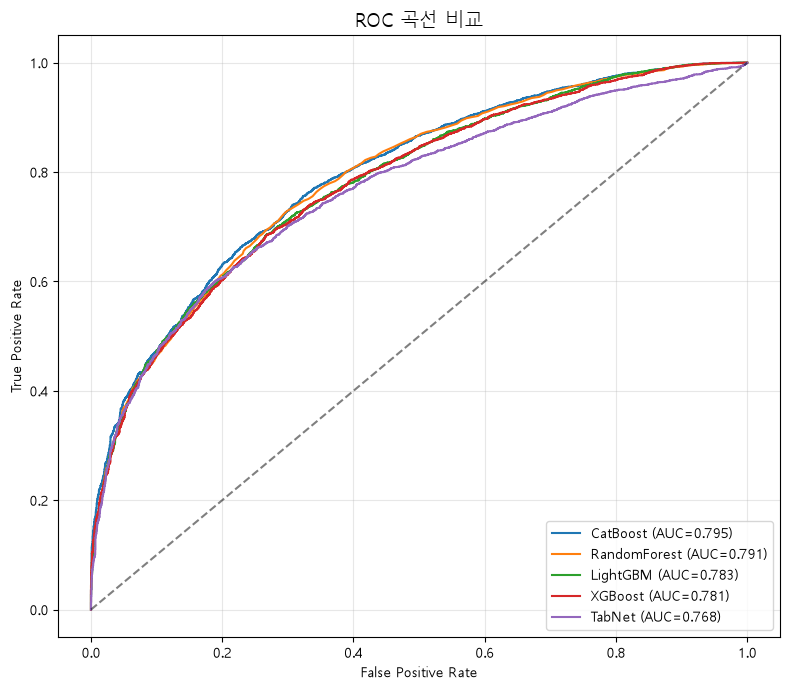

In [9]:
# ROC 곡선 비교
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))
for name in results_df.index:
    fpr, tpr, _ = roc_curve(y_test, roc_data[name])
    auc = results_df.loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC 곡선 비교', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 최종 모델 선택

**CatBoost**가 Accuracy / F1 / ROC-AUC **세 지표 모두에서 1위**로, 최종 모델로 선택합니다.

### 선택 근거
1. **성능**: 모든 지표에서 최고 (F1과 AUC 동시 우위)
2. **범주형 처리**: 자치구/업종 같은 범주형을 별도 인코딩 손실 없이 직접 처리
3. **안정성**: 기본 하이퍼파라미터에서도 과적합 없이 견고한 성능

→ 다음: `05_catboost_final.ipynb` — CatBoost에 Optuna 튜닝을 적용한 최종 모델

In [10]:
best_model = results_df.index[0]
print(f'최종 선택 모델: {best_model}')
print(results_df.loc[best_model].round(4).to_string())

최종 선택 모델: CatBoost
Accuracy    0.7127
F1-Score    0.6944
ROC-AUC     0.7955
